In [2]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else(x))

#Filter for Data Analyst data
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()


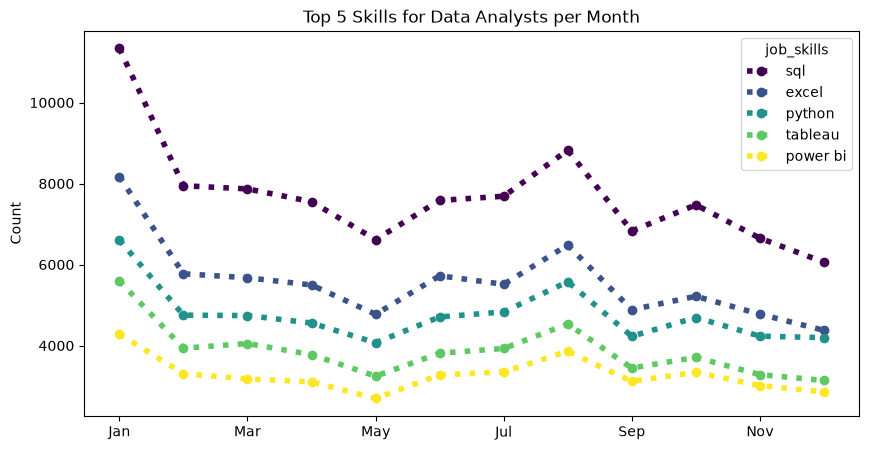

In [3]:
#adding a column for the Month Number
df_DA['job_posted_month_no'] = df_DA['job_posted_date'].dt.month

#explode the job_skills column and pivot
df_DA_exploded = df_DA.explode('job_skills')
df_DA_pivot = df_DA_exploded.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)

# sort the skills by count
df_DA_pivot.loc['Total'] = df_DA_pivot.sum()
df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending=False).index]
df_DA_pivot = df_DA_pivot.drop('Total')

#Us month name for plotting 
df_DA_pivot = df_DA_pivot.reset_index()
df_DA_pivot['job_posted_month']= df_DA_pivot['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_pivot = df_DA_pivot.set_index('job_posted_month')
df_DA_pivot = df_DA_pivot.drop(columns='job_posted_month_no')

# Get the top 5 skills
df_DA_pivot.iloc[:,:5].plot(
    kind='line',
    linewidth=4,
    linestyle= ':',
    colormap='viridis',
    marker= 'o',
    markersize=6,
    figsize=(10,5)
)

plt.title('Top 5 Skills for Data Analysts per Month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

In [4]:
skill_stats = df_DA_exploded.groupby('job_skills').agg(
    median_salary=('salary_year_avg','median'),
    skill_count= ('job_skills', 'count')
)

skill_count = 20
skill_stats= skill_stats.sort_values(by='skill_count',ascending=False).head(skill_count)

skill_stats

,median_salary,skill_count
job_skills,,
sql,92500.000000,92428
excel,84479.000000,66860
python,98500.000000,57190
tableau,95000.000000,46455
power bi,90000.000000,39380
r,92527.500000,29996
sas,90000.000000,27998
powerpoint,85000.000000,13822
word,80000.000000,13562


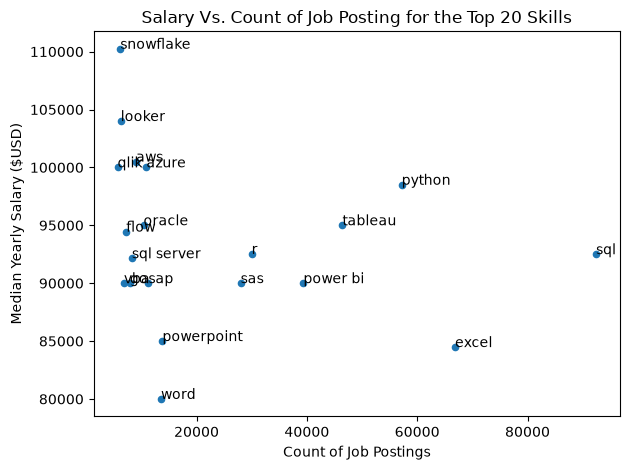

In [5]:
skill_stats.plot( kind='scatter',x='skill_count', y='median_salary')

for i, txt in enumerate(skill_stats.index):
    plt.text(skill_stats['skill_count'].iloc[i],skill_stats['median_salary'].iloc[i],txt)

plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title(f'Salary Vs. Count of Job Posting for the Top {skill_count} Skills')
plt.tight_layout()
plt.show()

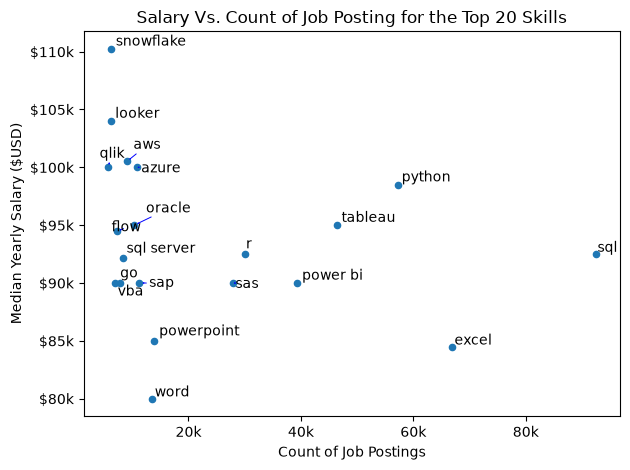

In [13]:
from adjustText import adjust_text
skill_stats.plot( kind='scatter',x='skill_count', y='median_salary')

texts= []

for i, txt in enumerate(skill_stats.index):
    texts.append(
    plt.text(skill_stats['skill_count'].iloc[i],skill_stats['median_salary'].iloc[i],txt)
    )
  

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='b', lw=0.7))


ax= plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos: f'${int(y/1000)}k'))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{int(x/1000)}k'))

plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title(f'Salary Vs. Count of Job Posting for the Top {skill_count} Skills')
plt.tight_layout()
plt.show()